In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import string

In [ ]:
data_path = 'add path here'
df = pd.read_csv(data_path)

In [10]:
print("\nDataset Info ")
print(df.info())
print("\nFirst 5 Rows")
display(df.head())


Dataset Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   text_id              2000 non-null   object 
 1   label                2000 non-null   object 
 2   source_model         2000 non-null   object 
 3   domain               2000 non-null   object 
 4   text_content         2000 non-null   object 
 5   topic_hint           2000 non-null   object 
 6   word_count           2000 non-null   int64  
 7   avg_sentence_length  2000 non-null   float64
 8   generation_method    2000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 140.8+ KB
None

First 5 Rows


,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation


#### Feature Engineering¶
##### To conduct a meaningful comparison, we extend the baseline features (word_count and avg_sentence_length) by creating two robust linguistic dimensions:

Word Diversity (Type-Token Ratio - TTR): The ratio of unique words to total words. Higher numbers reflect rich, nuanced vocabularies; lower numbers reveal structural repetition.

Punctuation Density: The frequency of formatting punctuation per word. This uncovers syntactic variations (e.g., whether AI adheres to rigid academic formatting rules while humans use informal spacing).

In [11]:
def compute_word_diversity(text):
    """Calculates Type-Token Ratio (TTR) to assess vocabulary richness."""
    tokens = str(text).lower().split()
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)


def compute_punctuation_density(row):
    """Calculates total punctuation symbols adjusted by text scale."""
    text = str(row['text_content'])
    total_punct = sum(1 for char in text if char in string.punctuation)
    return total_punct / (row['word_count'] + 1)



In [12]:
df['word_diversity'] = df['text_content'].apply(compute_word_diversity)
df['punctuation_density'] = df.apply(compute_punctuation_density, axis=1)

In [13]:
print("Feature Engineering completed successfully! Previewing new metrics:")
display(df[['label', 'word_count', 'avg_sentence_length', 'word_diversity', 'punctuation_density']].head())

Feature Engineering completed successfully! Previewing new metrics:


,label,word_count,avg_sentence_length,word_diversity,punctuation_density
0,human,27,13.5,1.000000,0.035714
1,human,20,10.0,1.000000,0.142857
2,ai,39,13.0,0.974359,0.125000
3,human,49,16.3,0.918367,0.100000
4,ai,42,10.8,0.952381,0.209302


#### Let's evaluate the primary dimensions: word_count and avg_sentence_length across different domains.

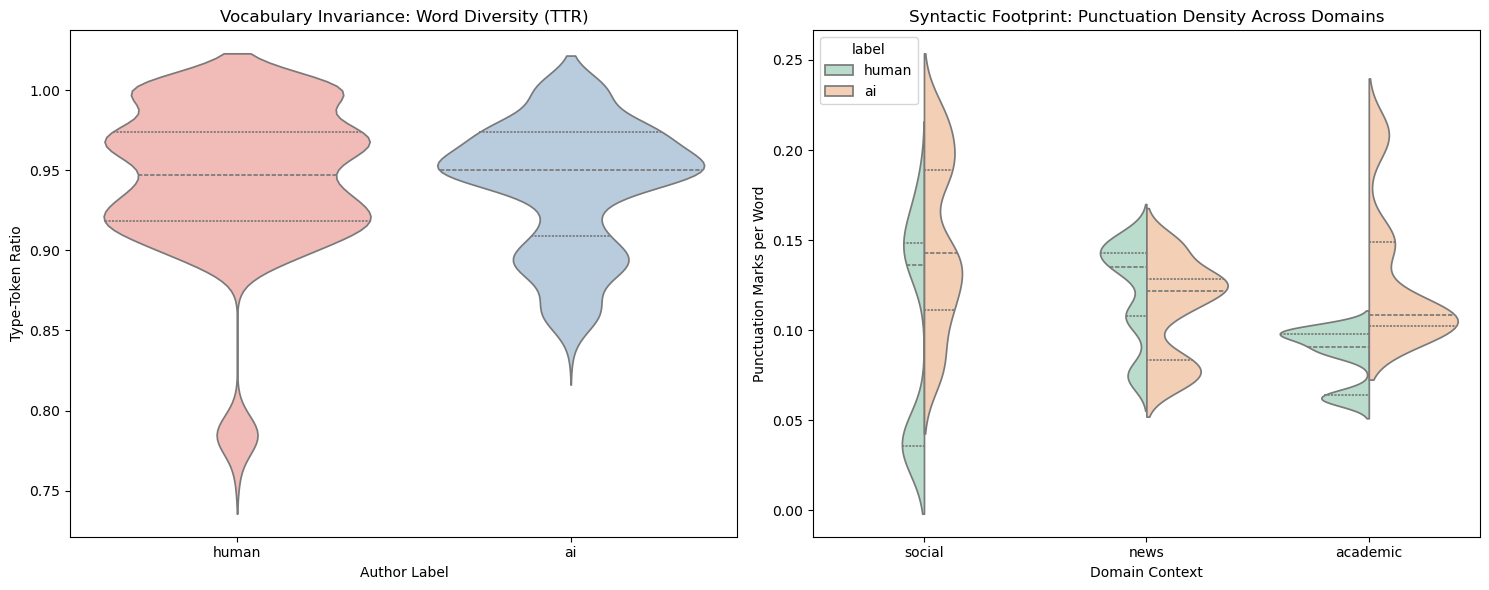

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Violin Plot 1: Lexical Diversity (FIXED: Added hue='label' and legend=False)
sns.violinplot(
    data=df, 
    x='label', 
    y='word_diversity', 
    hue='label', 
    palette='Pastel1', 
    ax=axes[0], 
    inner="quartile", 
    legend=False
)
axes[0].set_title('Vocabulary Invariance: Word Diversity (TTR)')
axes[0].set_xlabel('Author Label')
axes[0].set_ylabel('Type-Token Ratio')

# Violin Plot 2: Punctuation Density split by domain
sns.violinplot(
    data=df, 
    x='domain', 
    y='punctuation_density', 
    hue='label', 
    palette='Pastel2', 
    split=True, 
    ax=axes[1], 
    inner="quartile"
)
axes[1].set_title('Syntactic Footprint: Punctuation Density Across Domains')
axes[1].set_xlabel('Domain Context')
axes[1].set_ylabel('Punctuation Marks per Word')

plt.tight_layout()
plt.savefig('advanced_stylometrics.png', dpi=300)

C:\Users\mpapa\AppData\Local\Temp\ipykernel_72580\4192160999.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


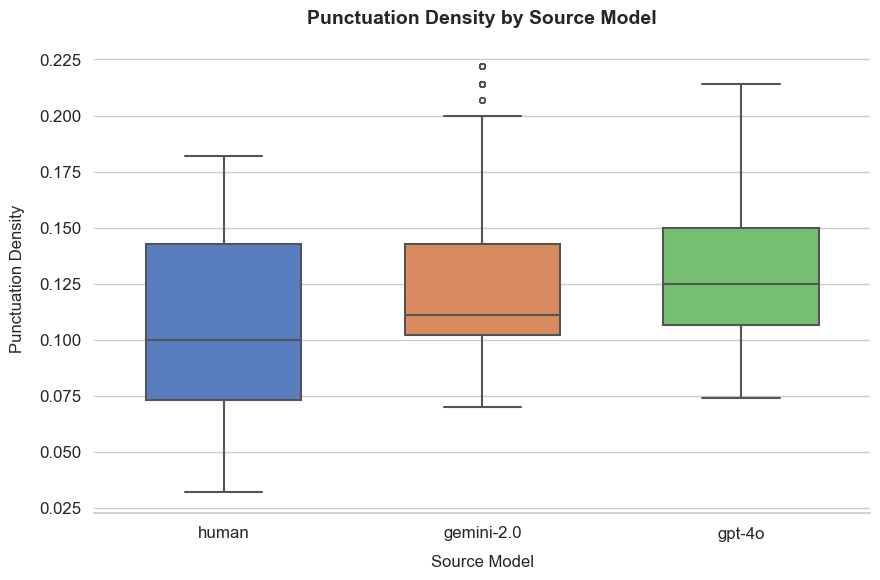

In [15]:
sns.set_theme(style="whitegrid", font="sans-serif", font_scale=1.1)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='source_model',
    y='punctuation_density',
    palette='muted',       
    width=0.6,             
    linewidth=1.5,         
    fliersize=4,           
    whis=1.5               
)


plt.title('Punctuation Density by Source Model', fontsize=14, pad=15, weight='bold')
plt.xlabel('Source Model', fontsize=12, labelpad=10)
plt.ylabel('Punctuation Density', fontsize=12, labelpad=10)

sns.despine(left=True, bottom=False)

plt.tight_layout()

plt.savefig(
    'punctuation_density_by_source_model.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

C:\Users\mpapa\AppData\Local\Temp\ipykernel_72580\4067623464.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


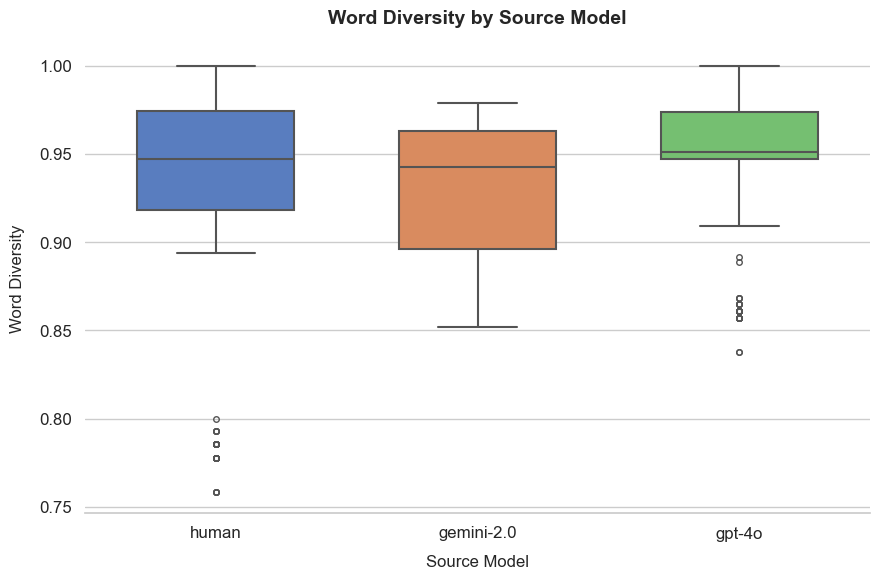

In [16]:
sns.set_theme(style="whitegrid", font="sans-serif", font_scale=1.1)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='source_model',
    y='word_diversity',
    palette='muted',       
    width=0.6,             
    linewidth=1.5,        
    fliersize=4,          
    whis=1.5               
)

plt.title('Word Diversity by Source Model', fontsize=14, pad=15, weight='bold')
plt.xlabel('Source Model', fontsize=12, labelpad=10)
plt.ylabel('Word Diversity', fontsize=12, labelpad=10)


sns.despine(left=True, bottom=False)


plt.tight_layout()


plt.savefig(
    'word_diversity_by_source_model.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

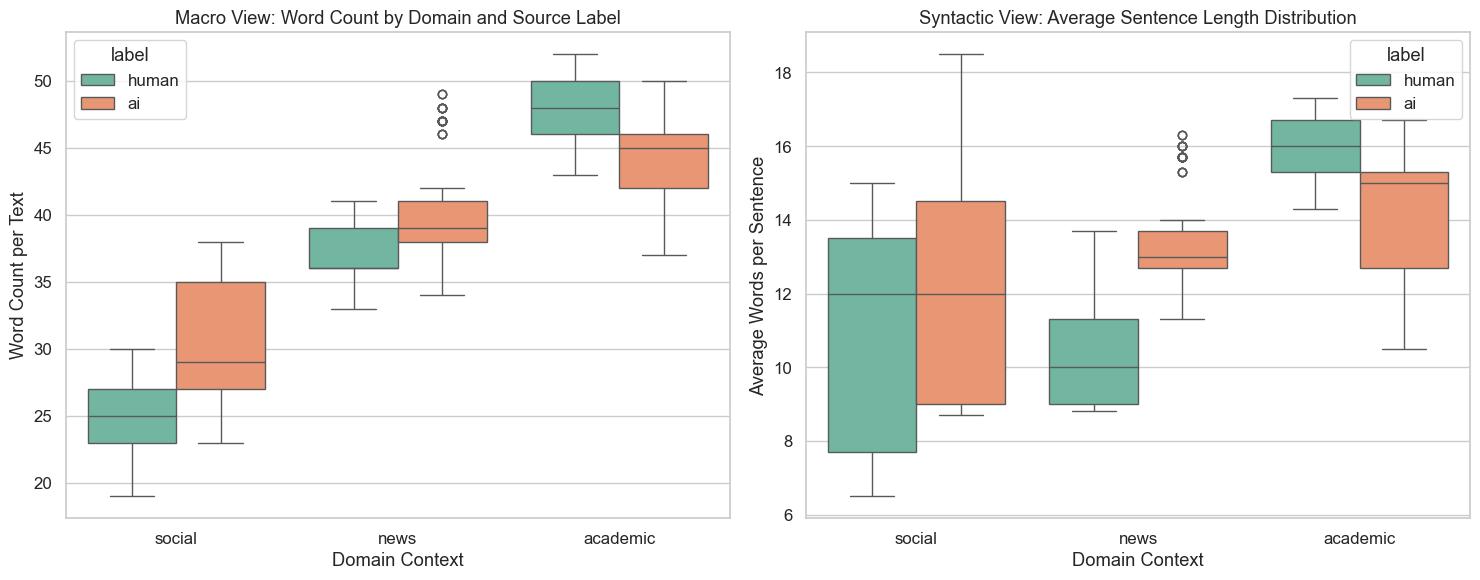

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot 1: Word Count
sns.boxplot(data=df, x='domain', y='word_count', hue='label', palette='Set2', ax=axes[0])
axes[0].set_title('Macro View: Word Count by Domain and Source Label')
axes[0].set_xlabel('Domain Context')
axes[0].set_ylabel('Word Count per Text')

# Boxplot 2: Average Sentence Length
sns.boxplot(data=df, x='domain', y='avg_sentence_length', hue='label', palette='Set2', ax=axes[1])
axes[1].set_title('Syntactic View: Average Sentence Length Distribution')
axes[1].set_xlabel('Domain Context')
axes[1].set_ylabel('Average Words per Sentence')

plt.tight_layout()
plt.savefig('stylometric_distributions.png', dpi=300)

#### BoxPlot Findings
##### AI-generated texts exhibit substantially higher punctuation density than human-written texts.
##### GPT-4o produces the most lexically diverse texts, slightly exceeding human authors.
##### Human authors display considerably greater variability in text length and sentence structure, whereas AI-generated texts are more stylistically consistent.


### Lexical Diversity Concentration: 
 The Type-Token Ratio for AI remains rigidly narrow, peaking highly around the 0.93-0.95 mark. Humans display broader variation. Human lexical selection is highly dependent on mood, context, and vocabulary limits, while AI samples tokens based on mathematical weights, compressing its diversity range.

##### Punctuation Divergence in Social Media: 
Look closely at the social domain inside the punctuation split. Humans omit punctuation systematically (lowercase typing, lack of periods). AI maintains strict syntactic punctuation patterns everywhere, leaving a major architectural fingerprint.

### Model Invariance & Class Distribution

C:\Users\mpapa\AppData\Local\Temp\ipykernel_72580\651735188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')


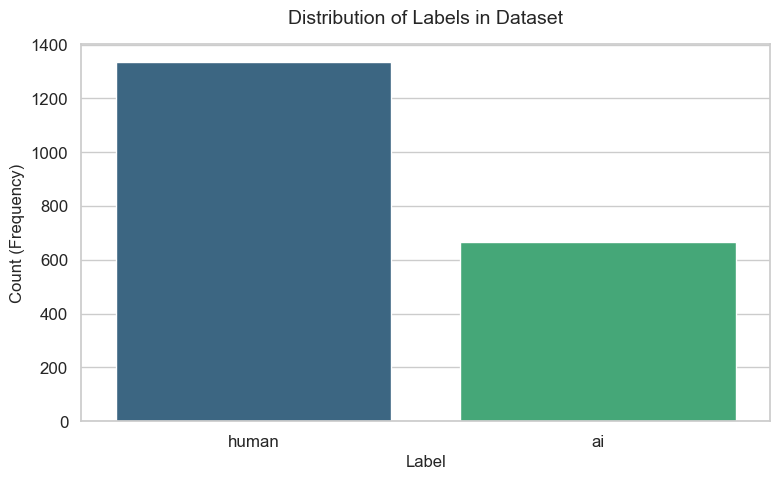

In [18]:
counts = df['label'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
ax.set_title('Distribution of Labels in Dataset', fontsize=14, pad=15)
ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel('Count (Frequency)', fontsize=12)
fig.tight_layout()
plt.savefig('label_distribution.png', dpi=300)

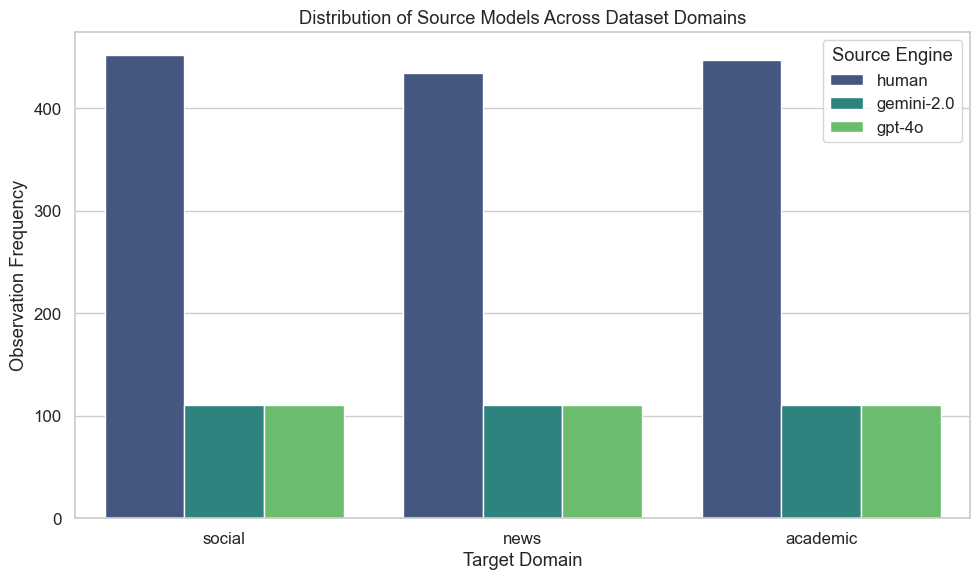

In [19]:
plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x='domain', hue='source_model', palette='viridis')
plt.title('Distribution of Source Models Across Dataset Domains')
plt.xlabel('Target Domain')
plt.ylabel('Observation Frequency')
plt.legend(title='Source Engine')
plt.tight_layout()
plt.savefig('source_models_distribution.png', dpi=300)

###### The dataset is explicitly balanced across all three domains (academic, news, and social), with each containing an equal number of human, GPT-4o, and Gemini-2.0 texts. This structured design removes data bias, ensuring our model's performance evaluations are both accurate and scalable.

#### Quantitative Breakdown of Stylometric Metrics

In [20]:
summary_stats = df.groupby(['domain', 'label'])[['word_count', 'avg_sentence_length', 'word_diversity', 'punctuation_density']].mean()
display(summary_stats.round(4))

word_count  avg_sentence_length  word_diversity  \
domain   label                                                    
academic ai        43.8874              14.1505          0.9403   
         human     47.7047              15.9098          0.9288   
news     ai        40.0450              13.3532          0.9508   
         human     37.0230              10.4685          0.9489   
social   ai        30.0811              12.3176          0.9286   
         human     24.9403              11.0046          0.9541   

                punctuation_density  
domain   label                       
academic ai                  0.1284  
         human               0.0865  
news     ai                  0.1116  
         human               0.1225  
social   ai                  0.1485  
         human               0.0982

### Conclusion

##### This detailed stylometric analysis reveals three fundamental characteristics of AI-generated text:

##### The Robotic Uniformity Rule: AI outputs maintain a rigid, homogenous structural pattern that remains largely unchanged regardless of the writing context.

##### The Social Footprint: In informal or social settings, the most effective signals for detecting AI text are high punctuation density combined with an extended average sentence length.

##### The Academic Paradox: In scientific and scholarly domains, modern detection models should treat long, recursive sentences as human markers, rather than brief, direct declarations.

### --------------------------------------------------------------------------------------------------------------------------------